# BeautifulSoup Documentation Analytics System

## Prerequisites

In [1]:
# This cell is for importing needed modules
from pathlib import Path
import sys

project_root = Path("..").resolve()   # one level up from notebooks
sys.path.append(str(project_root))

import pandas as pd

from src import main, analyzer, visualizer

## Dataset Overview

The dataset used in this project consists of the official BeautifulSoup documentation webpage. The HTML page was downloaded directly from the BeautifulSoup documentation website and stored locally for analysis. The purpose of the dataset is to examine the structure and content of the documentation by extracting textual information, hyperlinks, and Python code examples.

The extracted dataset contains three main components:

| Dataset       | Description                                                  |
| ------------- | ------------------------------------------------------------ |
| Sections      | Documentation headings, text content, hierarchy, word counts |
| Links         | Internal and external hyperlinks found in the documentation  |
| Code Examples | Python code snippets contained in the documentation          |

The processing pipeline successfully extracted 111 documentation sections. 

## Scraping Method

The project follows a complete web scraping pipeline implemented using Python.

### Download HTML

The documentation page was downloaded using an HTTP request and saved as a local HTML file.

In [2]:
main.download_html()

FEATURE 1 - WEB PAGE COLLECTOR
HTTP Status Code: 200
Download completed.
Saved to: E:\Anh Minh\bad codes\python\pds301m\PDS301m---Group-4\FinalProject\FinalProject\data\raw\beautifulsoup_doc.html


Output:
- HTTP Status Code: 200
- HTML downloaded successfully

### Parse HTML

The downloaded HTML document was parsed using the BeautifulSoup library to create a navigable document object.

In [3]:
main.parse_html(verbose=True); # Semicolon to surpress output


FEATURE 2 - HTML PARSER
HTML parsed successfully.


### Extract Data

Three extraction modules were implemented:
- Section extractor
- Link extractor
- Code example extractor

Each extracted dataset was exported into a CSV file for later analysis.

#### Sections

In [4]:
main.sections_to_csv()

File written to E:\Anh Minh\bad codes\python\pds301m\PDS301m---Group-4\FinalProject\FinalProject\data\processed\sections.csv


#### Links

In [5]:
main.links_to_csv()

File written to E:\Anh Minh\bad codes\python\pds301m\PDS301m---Group-4\FinalProject\FinalProject\data\processed\links.csv


#### Code Examples

In [6]:
main.code_samples_to_csv()

File written to E:\Anh Minh\bad codes\python\pds301m\PDS301m---Group-4\FinalProject\FinalProject\data\processed\code_examples.csv


## Extracted Data Summary

The scraping process produced structured datasets describing the documentation.
Documentation Statistics

| Metric                 | Result             |
| ---------------------- | ------------------ |
| Number of Sections     | 111                |
| Internal Links         | 396                |
| External Links         | 30                 |
| Average Section Length | 363.04 words       |
| Longest Section        | Searching the tree |
| Maximum Word Count     | 4612 words         |

The largest section is Searching the tree, containing:
- 4612 words
- 189 code examples
- 93 hyperlinks

making it the most comprehensive section in the documentation.

## Analysis Results

In [7]:
# This cell to load data for analysis
analyzer.load_data()

### Number of Sections

In [8]:
print(f"Number of sections: {int(analyzer.sections_count())}")

Number of sections: 111


### Section with the highest word count

In [9]:
df = pd.DataFrame(analyzer.section_with_longest_count())
df

,29
section_id,searching-the-tree
section_level,1
section_title,Searching the tree ¶
section_text,Beautiful Soup defines a lot of methods for se...
word_count,4612
code_block_count,189
link_count,93


### Section with the most code examples

In [10]:
df = pd.DataFrame(analyzer.section_with_most_code_examples())
df

,29
section_id,searching-the-tree
section_level,1
section_title,Searching the tree ¶
section_text,Beautiful Soup defines a lot of methods for se...
word_count,4612
code_block_count,189
link_count,93


### Section with the most links

In [11]:
df = pd.DataFrame(analyzer.section_contains_most_links())
df

,29
section_id,searching-the-tree
section_level,1
section_title,Searching the tree ¶
section_text,Beautiful Soup defines a lot of methods for se...
word_count,4612
code_block_count,189
link_count,93


The section Searching the tree is the longest section in the documentation.

Statistics:
- Word count: 4612
- Code examples: 189
- Links: 93

This suggests that searching operations are the core functionality of BeautifulSoup and therefore require more detailed explanations and examples.

### Most frequent technical keywords

The ten most frequently occurring technical keywords are:

In [12]:
top_ten = analyzer.top_ten_technical_keyword()
df = pd.DataFrame(top_ten)
df.columns= ["Keyword", "Count"]
df.index = range(1, len(df) + 1) # So index starts from 1
df

,Keyword,Count
1,soup,1047
2,tag,928
3,class,559
4,html,505
5,string,425
6,example,419
7,link,413
8,find,395
9,com,383
10,href,378


These keywords indicate that the documentation primarily focuses on HTML parsing, tags, searching, and hyperlinks.

### Link Analysis

In [13]:
internal_links, external_links = analyzer.count_internal_and_external_links()
print(f"{internal_links} internal links and {external_links} external links.")

396 internal links and 30 external links.


This indicates that the documentation is highly interconnected, allowing readers to navigate between related topics while relying relatively little on external resources.

### Code Example Analysis

In [14]:
print(f"{analyzer.count_find_all()} examples use find_all()")

39 examples use find_all()


In [15]:
print(f"{analyzer.count_get_text()} examples use find_all()")

4 examples use find_all()


This demonstrates that ```find_all()``` is one of the most frequently demonstrated BeautifulSoup methods.

### Section Length Statistics

Section lengths vary considerably.

In [16]:
average, minimum, maximum, std_dev = analyzer.word_count_statistics()
print(f"Average: {average:.2f}")
print("Minimum:", minimum)
print("Maximum:", maximum)
print(f"Standard deviation: {std_dev:.2f}")

Average: 363.04
Minimum: 24
Maximum: 4612
Standard deviation: 557.83


The large standard deviation indicates substantial variation in section sizes, with some sections providing brief explanations while others serve as extensive tutorials.

### Longer than average sections

In [17]:
df2 = analyzer.sections_above_average()
df2.columns = ["Title", "Word Count"]
df2

,Title,Word Count
3,Quick Start ¶,422
4,Installing Beautiful Soup ¶,427
7,Kinds of objects ¶,1515
8,Multi-valued attributes ¶,414
12,Navigating the tree ¶,2051
13,Going down ¶,890
23,Going sideways ¶,454
26,Going back and forth ¶,378
29,Searching the tree ¶,4612
30,Kinds of filters ¶,597


## Visualization Charts

### Top 10 sections by word count 

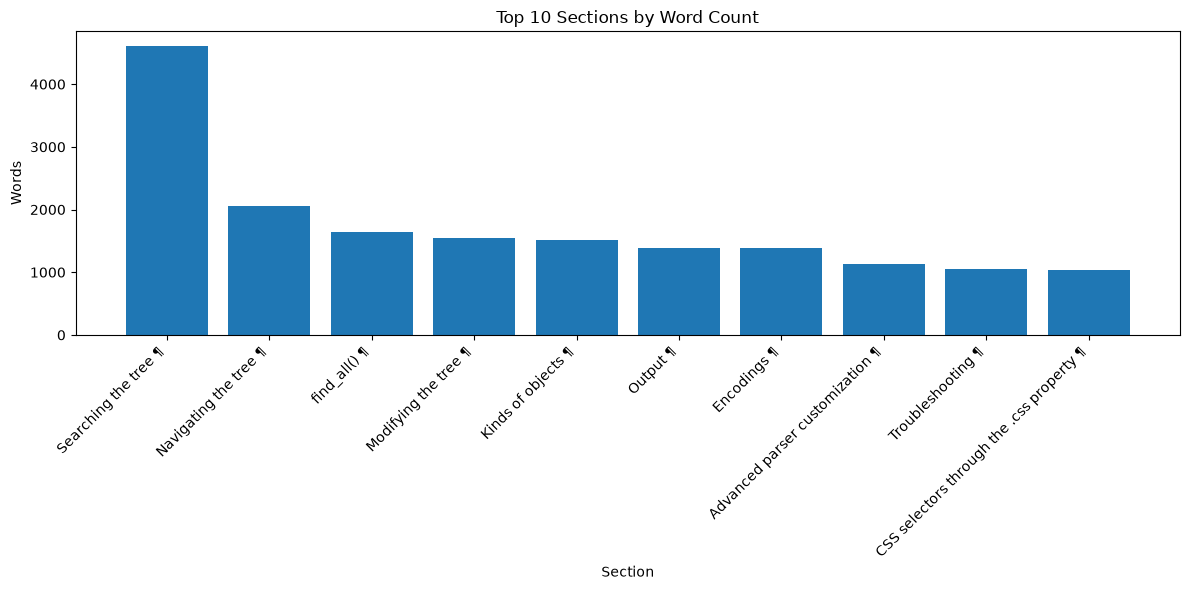

In [18]:
visualizer.chart_top10_sections()

### Number of code examples by section 

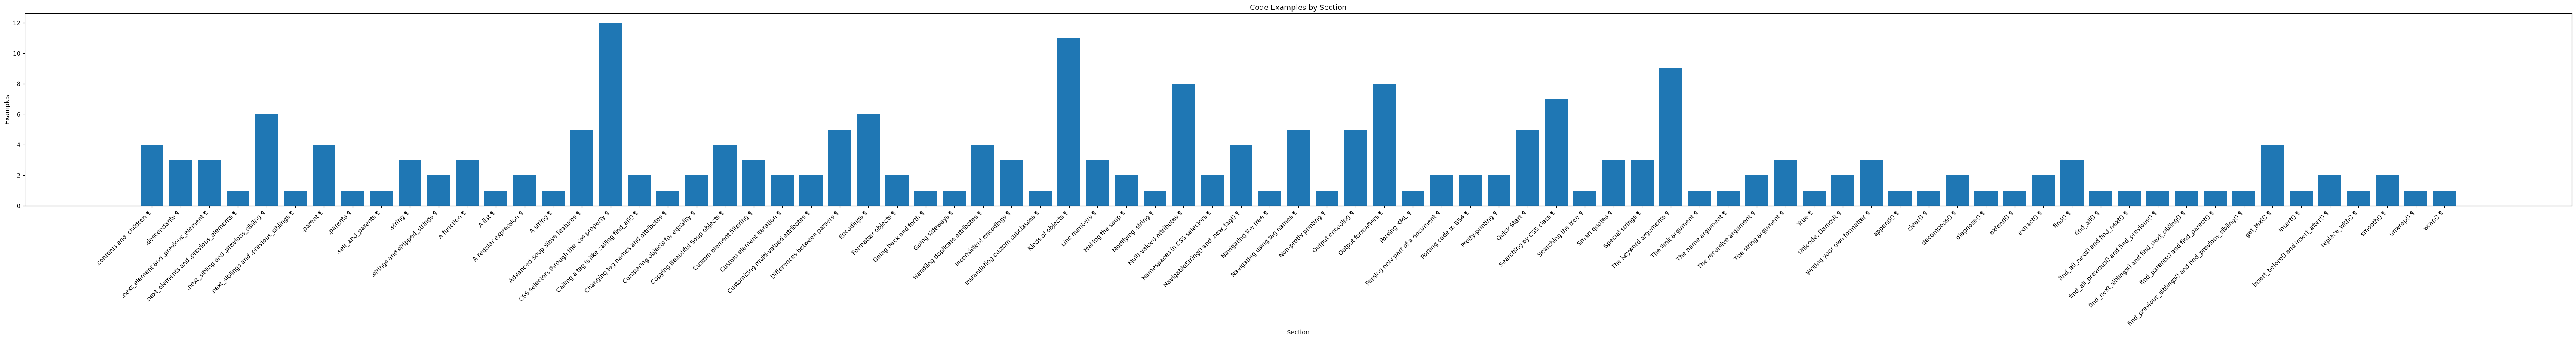

In [19]:
visualizer.chart_code_examples()

### Link type distribution

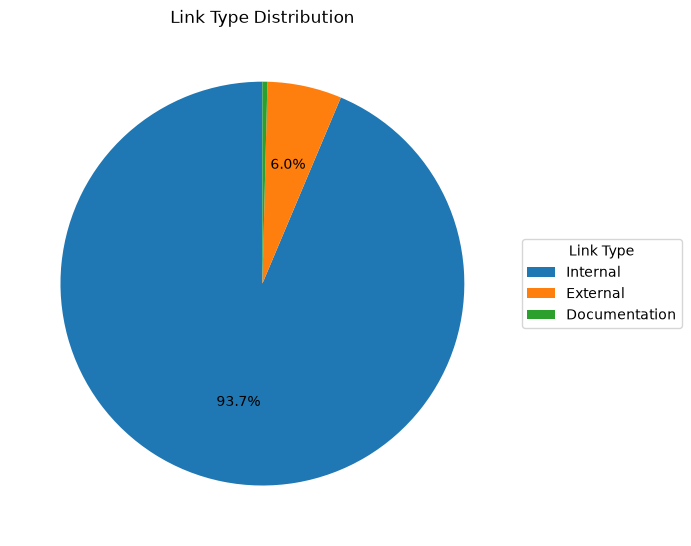

In [20]:
visualizer.chart_link_distribution()

### Code example line count distribution   

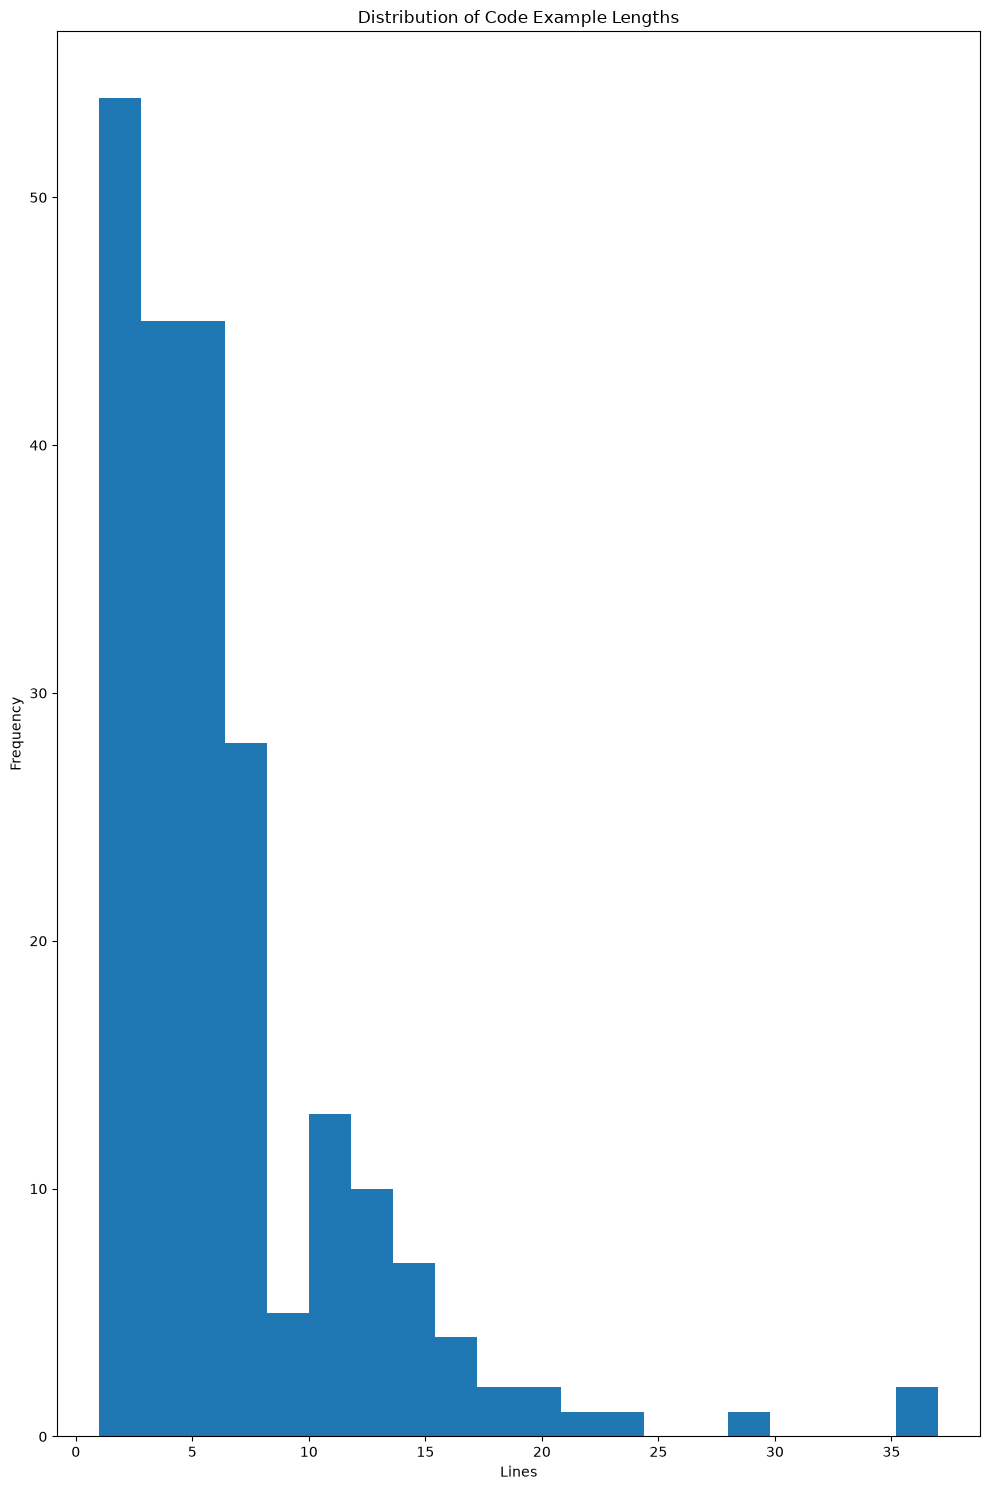

In [21]:
visualizer.chart_code_length_histogram()

## Key Findings

The project reveals several insights about the BeautifulSoup documentation:
- The documentation contains 111 structured sections covering a wide range of topics.
- Searching the tree is the largest and most comprehensive section, suggesting that searching functionality is central to BeautifulSoup.
- Internal hyperlinks significantly outnumber external hyperlinks, making the documentation highly interconnected.
- The keyword analysis confirms that the documentation emphasizes HTML parsing, tags, and searching operations.
- ``find_all()`` appears much more frequently than ``get_text()``, reflecting its importance in common BeautifulSoup workflows.
- Documentation section lengths vary widely, with a few detailed tutorial sections and many shorter reference sections.


## Limitations

Several limitations should be considered:
- The analysis is based on a single snapshot of the BeautifulSoup documentation; future updates may change the results.
- Only one webpage was analyzed, so the findings cannot be generalized to other documentation websites.
- Keyword frequency does not capture semantic meaning or context.
- Code examples were analyzed mainly by counting occurrences rather than evaluating their complexity or functionality.
- Dynamic content loaded through JavaScript would not be captured by this scraping approach (though this is not a major issue for the BeautifulSoup documentation).


## Conclusion

This project successfully developed an end-to-end documentation analytics system using Python and BeautifulSoup. The system automatically downloaded, parsed, extracted, analyzed, and visualized information from the BeautifulSoup documentation.

The analysis showed that the documentation is well structured, heavily interconnected through internal links, and centered around searching-related functionality. Automated extraction and visualization provided valuable insights into documentation organization, keyword usage, code examples, and content distribution. Overall, the project demonstrates how web scraping and data analysis techniques can be used to better understand and evaluate technical documentation.